# 데이터와 특성 중요도 쉬운 개념 튜토리얼

**핵심 질문**
- 의사결정나무는 어떤 기준으로 데이터를 나누는가?
- Gini와 Entropy는 어떻게 계산되는가?
- `max_depth`가 커지면 모델 결과가 어떻게 달라지는가?
- Feature Importance는 모델마다 어떤 의미인가?
- 특성 엔지니어링은 모델별로 왜 다르게 중요해지는가?


---
## 0. 환경 설정과 tips 데이터 준비

`tips` 데이터는 식사 금액, 팁, 요일, 시간대, 흡연 여부, 인원 수 등을 담고 있습니다. 여기서는 개념 이해를 위해 두 가지 문제를 만듭니다.

- **분류 문제**: `tip_rate = tip / total_bill`이 중앙값 이상이면 `high_tip=1`
- **회귀 문제**: 실제 팁 금액 `tip` 예측


In [1]:
import sys
import warnings

# 1. 운영체제 확인 및 나눔 폰트 설치 (리눅스 환경 전용)
# Mac(darwin)이 아닌 리눅스(예: Colab) 환경일 때 한글 깨짐 방지를 위해 나눔 폰트를 설치합니다.
if sys.platform != 'darwin':
    # -qq 옵션으로 조용히 설치하고, 에러 메시지는 2>/dev/null로 숨깁니다.
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    # 시스템 폰트 캐시를 갱신합니다.
    !fc-cache -fv 2>/dev/null
    # Matplotlib의 예전 폰트 캐시를 삭제하여 새로 설치된 폰트를 인식하게 합니다.
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 2. 필수 라이브러리 로드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 3. 사이킷런(Scikit-learn) 머신러닝 모듈 로드
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 4. 경고 메시지 무시 및 무작위성(Seed) 고정
warnings.filterwarnings('ignore') # 실행 시 발생하는 불필요한 경고창을 숨깁니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)       # 코드 재실행 시에도 동일한 결과가 나오도록 시드를 고정합니다.

# 5. 설치된 나눔 폰트를 Matplotlib 시스템에 등록
# 리눅스 경로와 Mac 경로를 모두 탐색하며 폰트를 추가합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# 6. 시각화(Matplotlib, Seaborn) 기본 스타일 및 한글 폰트 설정
# 폰트를 'NanumBarunGothic'으로 지정하고, 마이너스(-) 기호가 깨지는 현상을 방지합니다.
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

print('환경 설정 완료')

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

In [2]:
# 1. Seaborn의 기본 제공 데이터셋인 'tips'(팁 팁 데이터) 로드
tips = sns.load_dataset('tips')

# 2. 파생 변수 생성 (계산 및 이진화 처리)
# 전체 금액(total_bill) 대비 팁(tip)의 비율을 계산하여 'tip_rate' 컬럼 생성
tips.loc[:, 'tip_rate'] = tips.loc[:, 'tip'] / tips.loc[:, 'total_bill']

# 팁 비율의 중앙값(Median)을 기준으로, 이상이면 1, 미만이면 0으로 이진화 ('high_tip')
tips.loc[:, 'high_tip'] = (tips.loc[:, 'tip_rate'] >= tips.loc[:, 'tip_rate'].median()).astype(int)

# 흡연 여부가 'Yes'이면 1, 'No'이면 0으로 변환 ('smoker_yes')
tips.loc[:, 'smoker_yes'] = (tips.loc[:, 'smoker'] == 'Yes').astype(int)

# 식사 시간대가 'Dinner'이면 1, 'Lunch'이면 0으로 변환 ('dinner')
tips.loc[:, 'dinner'] = (tips.loc[:, 'time'] == 'Dinner').astype(int)

# 요일이 주말('Sat', 'Sun')에 해당하면 1, 평일('Thur', 'Fri')이면 0으로 변환 ('weekend')
tips.loc[:, 'weekend'] = tips.loc[:, 'day'].isin(['Sat', 'Sun']).astype(int)

# 3. 데이터 확인 및 결과 출력
# 데이터프레임의 행과 열 개수(차원) 출력
print('shape:', tips.shape)

# 타겟 변수로 사용할 'high_tip'의 클래스별(0과 1) 데이터 분포 확인
print('high_tip 분포:')
print(tips.loc[:, 'high_tip'].value_counts().sort_index())

# 새로 생성된 컬럼들을 포함한 데이터프레임의 상위 5개 행 출력
tips.head()

shape: (244, 12)
high_tip 분포:
high_tip
0    122
1    122
Name: count, dtype: int64


,total_bill,tip,sex,smoker,day,time,size,tip_rate,high_tip,smoker_yes,dinner,weekend
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,0,0,1,1
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,1,0,1,1
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,1,0,1,1
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,0,0,1,1
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,0,0,1,1


---
## 1. Gini와 Entropy를 직접 계산하기

분류나무는 노드 안에 클래스가 얼마나 섞여 있는지를 봅니다. 이를 **불순도(impurity)** 라고 합니다.

$$Gini = 1 - \sum_k p_k^2$$

$$Entropy = -\sum_k p_k \log_2(p_k)$$

- 한 클래스만 있으면 불순도는 0입니다.
- 0과 1이 반반 섞이면 불순도가 큽니다.


In [3]:
# 1. 클래스별 확률(비율) 계산 함수
def class_probabilities(y_values):
    # 입력 데이터를 넘파이 배열(Array) 형태로 변환합니다.
    y_values = np.asarray(y_values)
    # 고유한 클래스(라벨)와 각 클래스의 등장 빈도(counts)를 반환합니다.
    _, counts = np.unique(y_values, return_counts=True)
    # 각 클래스의 빈도를 전체 데이터 개수로 나누어 확률 $p_i$ 배열을 반환합니다.
    return counts / counts.sum()


# 2. 지니 불순도(Gini Impurity) 계산 함수
# 공식: $Gini = 1 - \sum (p_i^2)$
def gini_impurity(y_values):
    p = class_probabilities(y_values)
    # 각 클래스 비율의 제곱 합을 1에서 빼서 계산합니다. (완전 순수할 때 0)
    return 1 - np.sum(p ** 2)


# 3. 엔트로피(Entropy) 계산 함수
# 공식: $Entropy = -\sum (p_i \times \log_2(p_i))$
def entropy_impurity(y_values):
    p = class_probabilities(y_values)
    # 각 클래스 비율에 밑이 2인 로그를 곱한 뒤 모두 더하고, 마이너스를 붙입니다.
    return -np.sum(p * np.log2(p))


# 4. 불순도 비교를 위한 테스트 데이터 정의 (0과 1의 범주형 데이터)
examples = {
    '순수함: [0, 0, 0, 0]': [0, 0, 0, 0],     # 하나의 클래스만 존재 (불순도 최저)
    '조금 섞임: [0, 0, 0, 1]': [0, 0, 0, 1],   # 불순도가 낮게 발생
    '반반 섞임: [0, 0, 1, 1]': [0, 0, 1, 1],   # 두 클래스가 동등하게 존재 (불순도 최고)
}

# 5. 반복문을 통해 예시별 불순도를 계산하고 데이터프레임으로 변환
impurity_df = pd.DataFrame([
    {
        '예시': name,
        '클래스 비율': np.round(class_probabilities(labels), 3), # 소수점 셋째 자리까지 반올림
        'Gini': gini_impurity(labels),
        'Entropy': entropy_impurity(labels),
    }
    for name, labels in examples.items()
])

# 결과 데이터프레임 출력
impurity_df

,예시,클래스 비율,Gini,Entropy
0,"순수함: [0, 0, 0, 0]",[1.0],0.000,-0.000000
1,"조금 섞임: [0, 0, 0, 1]","[0.75, 0.25]",0.375,0.811278
2,"반반 섞임: [0, 0, 1, 1]","[0.5, 0.5]",0.500,1.000000


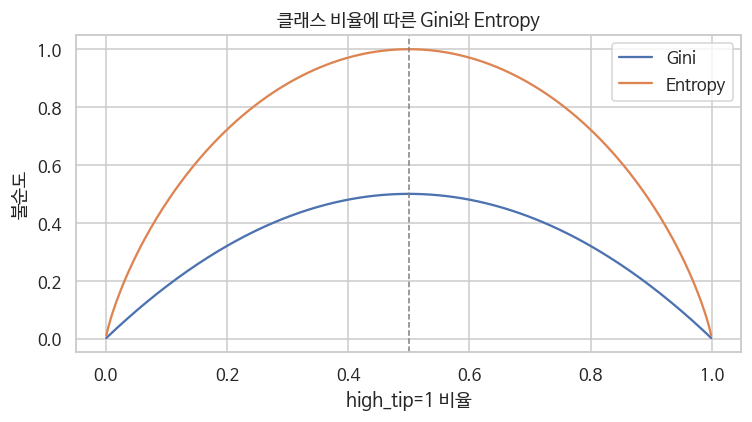

In [4]:
# 1. 시각화용 데이터 생성 (확률 p 값을 0.001부터 0.999까지 300개로 쪼갬)
# 로그 계산 시 p가 0이나 1이 되면 무한대(-inf)가 되므로 미세한 여백을 둡니다.
p = np.linspace(0.001, 0.999, 300)

# p 값에 따른 지니 불순도와 엔트로피를 계산하여 데이터프레임 구축
curve_df = pd.DataFrame({
    'p_high_tip': p,
    # 이진 분류 지니 공식: 1 - (p^2 + (1-p)^2)
    'Gini': 1 - (p ** 2 + (1 - p) ** 2),
    # 이진 분류 엔트로피 공식: -(p * log2(p) + (1-p) * log2(1-p))
    'Entropy': -(p * np.log2(p) + (1 - p) * np.log2(1 - p)),
})

# 2. 시각화 그리기
# 그래프의 크기(가로 7인치, 세로 4인치) 설정 및 축(ax) 생성
fig, ax = plt.subplots(figsize=(7, 4))

# 지니 불순도 곡선 그리기
sns.lineplot(data=curve_df, x='p_high_tip', y='Gini', label='Gini', ax=ax)

# 엔트로피 곡선 그리기
sns.lineplot(data=curve_df, x='p_high_tip', y='Entropy', label='Entropy', ax=ax)

# 불순도가 최대가 되는 지점인 p = 0.5 위치에 세로 점선 추가
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)

# 그래프 제목 및 축 레이블 설정
ax.set_title('클래스 비율에 따른 Gini와 Entropy')
ax.set_xlabel('high_tip=1 비율') # x축: 1번 클래스의 확률(비율)
ax.set_ylabel('불순도')            # y축: 불순도 값

# 요소들이 겹치지 않게 여백을 자동 조절한 후 화면에 출력
plt.tight_layout()
plt.show()

---
## 2. 분할조건은 어떻게 고르는가?

의사결정나무의 질문은 보통 이런 형태입니다.

> `total_bill <= 20.5` 인가?

좋은 질문은 부모 노드보다 자식 노드가 더 덜 섞이게 만드는 질문입니다.

$$Gain = I(parent) - \frac{n_L}{n}I(left) - \frac{n_R}{n}I(right)$$

`Gain`이 클수록 좋은 분할입니다.


In [5]:
# 1. 자식 노드들의 가중 평균 불순도 계산 함수
def weighted_child_impurity(y_left, y_right, criterion='gini'):
    # 분할 기준(지니 또는 엔트로피)에 따라 불순도 계산 함수를 선택합니다.
    impurity_func = gini_impurity if criterion == 'gini' else entropy_impurity

    # 왼쪽, 오른쪽 자식 노드의 데이터 개수 및 전체 데이터 개수 계산
    n_left = len(y_left)
    n_right = len(y_right)
    n_total = n_left + n_right

    # 각 자식 노드의 데이터 비율을 불순도에 곱한 뒤 더합니다. (가중 평균 불순도)
    return (n_left / n_total) * impurity_func(y_left) + (n_right / n_total) * impurity_func(y_right)


# 2. 분할로 인한 정보 획득량(Split Gain) 계산 함수
# 공식: Gain = 부모 노드 불순도 - 자식 노드들의 가중 평균 불순도
def split_gain(y_parent, y_left, y_right, criterion='gini'):
    impurity_func = gini_impurity if criterion == 'gini' else entropy_impurity
    return impurity_func(y_parent) - weighted_child_impurity(y_left, y_right, criterion)


# 3. 특정 변수와 임곗값(Threshold)을 기준으로 분할 효과를 평가하는 함수
def evaluate_threshold(data, feature, target, threshold, criterion='gini'):
    # 지정한 임곗값(threshold) 이하인 데이터를 왼쪽 자식 노드로 분할
    left = data.loc[data[feature] <= threshold, target].to_numpy()
    # 지정한 임곗값(threshold) 초과인 데이터를 오른쪽 자식 노드로 분할
    right = data.loc[data[feature] > threshold, target].to_numpy()
    # 분할 전 부모 노드의 데이터
    parent = data.loc[:, target].to_numpy()

    # 분할 결과에 대한 주요 지표를 딕셔너리 형태로 반환
    return {
        'feature': feature,                             # 분할에 사용된 변수명
        'threshold': threshold,                         # 분할 임곗값
        'left_n': len(left),                            # 왼쪽 자식 노드의 데이터 수
        'right_n': len(right),                          # 오른쪽 자식 노드의 데이터 수
        'left_high_tip_rate': left.mean(),              # 왼쪽 자식 노드의 high_tip 비율(1의 비율)
        'right_high_tip_rate': right.mean(),            # 오른쪽 자식 노드의 high_tip 비율(1의 비율)
        'gain': split_gain(parent, left, right, criterion), # 이 분할로 얻은 정보 획득량 (높을수록 좋음)
    }


# 4. total_bill 변수에 대해 여러 임곗값을 적용하며 성능 테스트
demo_thresholds = [12, 16, 20, 24, 28, 32]

# 설정한 임곗값 리스트를 순회하면서 결과를 계산하고, 데이터프레임으로 시각화합니다.
pd.DataFrame([
    evaluate_threshold(tips, 'total_bill', 'high_tip', threshold, criterion='gini')
    for threshold in demo_thresholds
]).round(4) # 가독성을 위해 소수점 넷째 자리까지 반올림

,feature,threshold,left_n,right_n,left_high_tip_rate,right_high_tip_rate,gain
0,total_bill,12,40,204,0.7000,0.4608,0.0157
1,total_bill,16,96,148,0.5729,0.4527,0.0069
2,total_bill,20,147,97,0.5782,0.3814,0.0185
3,total_bill,24,180,64,0.5722,0.2969,0.0293
4,total_bill,28,203,41,0.5468,0.2683,0.0217
5,total_bill,32,219,25,0.5342,0.2000,0.0205


Gini 기준 best split


,feature,threshold,left_n,right_n,left_high_tip_rate,right_high_tip_rate,gain
0,total_bill,22.580,171,73,0.5848,0.3014,0.0337
1,total_bill,23.505,178,66,0.5787,0.2879,0.0334
2,total_bill,26.150,195,49,0.5641,0.2449,0.0327
3,total_bill,22.710,172,72,0.5814,0.3056,0.0317
4,total_bill,23.815,179,65,0.5754,0.2923,0.0313


Entropy 기준 best split


,feature,threshold,left_n,right_n,left_high_tip_rate,right_high_tip_rate,gain
0,total_bill,22.580,171,73,0.5848,0.3014,0.0496
1,total_bill,23.505,178,66,0.5787,0.2879,0.0493
2,total_bill,26.150,195,49,0.5641,0.2449,0.0490
3,total_bill,22.710,172,72,0.5814,0.3056,0.0466
4,total_bill,23.815,179,65,0.5754,0.2923,0.0463


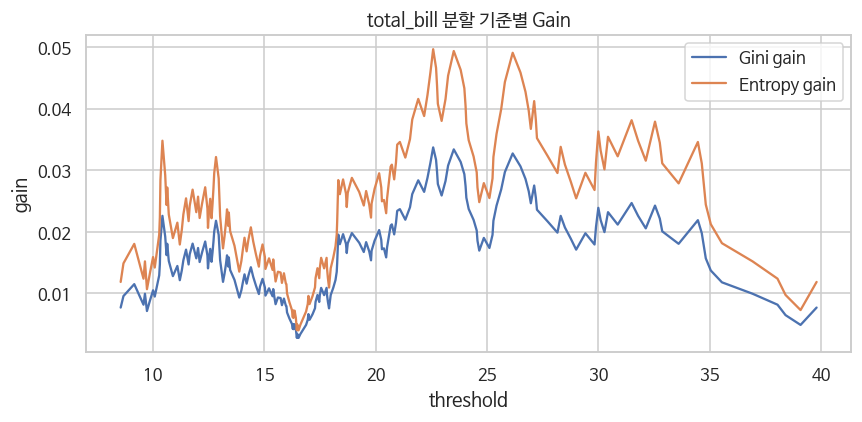

In [6]:
# 1. 연속형 변수의 모든 임곗값 후보에 대해 Gain을 계산하는 함수
def all_threshold_gains(data, feature, target, criterion='gini'):
    # 해당 변수의 고유값들을 가져와 오름차순으로 정렬합니다.
    values = np.sort(data.loc[:, feature].unique())
    # 연속한 두 값의 중간값들을 모두 구하여 임곗값(Threshold) 후보로 설정합니다.
    thresholds = (values[:-1] + values[1:]) / 2

    rows = []
    for threshold in thresholds:
        # 현재 임곗값 기준으로 왼쪽과 오른쪽 자식 노드에 들어갈 데이터 개수를 계산합니다.
        left_n = (data.loc[:, feature] <= threshold).sum()
        right_n = (data.loc[:, feature] > threshold).sum()

        # 과적합 방지(가지치기): 한쪽이라도 데이터가 너무 적으면(10개 미만) 분할 후보에서 제외합니다.
        if left_n < 10 or right_n < 10:
            continue

        # 앞서 정의한 evaluate_threshold 함수를 이용해 분할 지표를 계산하고 리스트에 추가합니다.
        rows.append(evaluate_threshold(data, feature, target, threshold, criterion))

    # 결과를 데이터프레임으로 만든 뒤, Gain이 높은 순(내림차순)으로 정렬하여 인덱스를 재정의합니다.
    return pd.DataFrame(rows).sort_values('gain', ascending=False).reset_index(drop=True)


# 2. total_bill 변수에 대해 Gini와 Entropy를 각각 기준으로 삼아 모든 후보 평가
gini_gain_df = all_threshold_gains(tips, 'total_bill', 'high_tip', criterion='gini')
entropy_gain_df = all_threshold_gains(tips, 'total_bill', 'high_tip', criterion='entropy')

# 3. 각 기준별로 가장 정보 획득량(Gain)이 높은 최적의 분할 상위 5개 출력
print('Gini 기준 best split')
display(gini_gain_df.head(5).round(4))

print('Entropy 기준 best split')
display(entropy_gain_df.head(5).round(4))

# 4. 임곗값 변화에 따른 정보 획득량(Gain) 추이 시각화
fig, ax = plt.subplots(figsize=(8, 4))

# 선 그래프를 그리기 위해 임곗값(threshold) 기준으로 데이터를 다시 정렬하여 시각화합니다.
sns.lineplot(data=gini_gain_df.sort_values('threshold'), x='threshold', y='gain', label='Gini gain', ax=ax)
sns.lineplot(data=entropy_gain_df.sort_values('threshold'), x='threshold', y='gain', label='Entropy gain', ax=ax)

# 그래프 레이블 및 타이틀 설정
ax.set_title('total_bill 분할 기준별 Gain')
ax.set_xlabel('threshold')
ax.set_ylabel('gain')

# 레이아웃 정돈 및 출력
plt.tight_layout()
plt.show()

### 결괏값 확인하기

- **최적의 분할 지점 발견:** 지니와 엔트로피 기준 모두에서 식사 금액 `total_bill = 22.580`이 정보 획득량(Gain)을 가장 극대화하는 최적의 분할 임곗값으로 일치하게 선택되었습니다.
- **지표별 경향성 일치:** 두 평가지표의 수학적 스케일(Y축 값)은 다르지만, 임곗값 변화에 따른 Gain의 증감 추이와 상위 5개 최적 분할 후보의 순위는 완벽히 동일한 패턴을 보입니다.

---

#### 1. 최적의 분할 지점 (Best Split Point)

지니 불순도(Gini)와 엔트로피(Entropy) 기준 모두에서 `total_bill = 22.580`이 정보 획득량(Gain)을 가장 크게 만드는 **최적의 임곗값**으로 선택되었습니다.

- **수치 해석 (`threshold = 22.580` 일 때):**
- **왼쪽 자식 노드 (`left_n = 171`):** 식사 금액이 $22.58 이하인 손님 171명 중 팁을 많이 준 비율(`left_high_tip_rate`)은 58.48%입니다.
- **오른쪽 자식 노드 (`right_n = 73`):** 식사 금액이 $22.58 초과인 손님 73명 중 팁을 많이 준 비율(`right_high_tip_rate`)은 30.14%입니다.
- **의미:** 이 지점을 기준으로 나눴을 때 두 그룹 간의 `high_tip` 비율 차이가 약 28.3%p로 뚜렷하게 갈라지며, 데이터의 불순도를 가장 많이 낮춰줍니다.



---

#### 2. 지니(Gini) vs 엔트로피(Entropy) 비교

- **최적의 위치 일치:** 두 평가지표의 수학적 수식과 스케일(Y축 값의 범위)은 다르지만, **Gain이 정점을 찍는 최적의 임곗값 위치(`22.580`, `23.505`, `26.150` 등)는 순위까지 완벽하게 일치**합니다.
- **실무적 의미:** 지니 불순도와 엔트로피 중 무엇을 선택하든 결정 트리가 데이터를 나누는 기준(경계면)에는 큰 차이가 없음을 보여줍니다. (보통 계산이 더 빠른 지니 불순도를 기본값으로 많이 씁니다.)

---

#### 3. 선 그래프(Gain 추이) 해석

아래의 라인 플롯은 `total_bill` 값을 얼마로 설정하느냐에 따라 트리가 얻는 이득(`gain`)이 어떻게 변하는지 보여줍니다.

- **쌍봉(Double Peak) 형태:** 그래프를 보면 `threshold`가 **22 ~ 23 부근**과 **26 부근**에서 크게 치솟는 두 개의 거대한 봉우리가 보입니다. 이 근처 값들이 데이터를 두 그룹으로 깨끗하게 쪼개는 우수한 분할 후보들입니다.
- **급격한 하락 구간:** `threshold`가 20 부근일 때는 Gain이 0.01 이하로 뚝 떨어집니다. 이 지점은 데이터를 나눠봤자 두 자식 노드의 `high_tip` 비율이 부모 노드와 별반 다르지 않아, 분할로서의 가치가 없는 지점입니다.
- **양 끝단의 생략:** 그래프 양 끝(식사 금액이 너무 적거나 너무 많은 구간)에 선이 끊기거나 없는 이유는, 앞선 코드에서 한쪽 노드에 최소 10개 이상의 데이터가 남도록 제한(가지치기)했기 때문입니다.


---
## 3. max_depth가 결과를 어떻게 바꾸는가?

`max_depth`는 나무가 질문을 몇 단계까지 이어갈 수 있는지를 정합니다.

- 너무 작으면 단순해서 중요한 패턴을 놓칠 수 있습니다. **과소적합**
- 너무 크면 학습 데이터를 지나치게 외울 수 있습니다. **과적합**
- 강의에서는 train accuracy와 test accuracy의 차이를 함께 봅니다.


In [7]:
# 1. 학습에 사용할 특성(Feature)과 타겟(Target) 분리
tree_feature_cols = ['total_bill', 'size', 'smoker_yes', 'dinner', 'weekend']
X = tips.loc[:, tree_feature_cols] # 독립변수 (예측에 사용할 변수들)
y = tips.loc[:, 'high_tip']        # 종속변수 (맞춰야 할 정답 라벨)

# 2. 데이터셋을 학습용(Train)과 검증용(Test)으로 분리 (7:3 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,          # 30%를 테스트 데이터로 사용
    stratify=y,             # 타겟 클래스(0, 1) 비율을 Train과 Test에 동일하게 유지
    random_state=RANDOM_STATE,
)

# 3. 최대 깊이(max_depth)별 모델 실험 진행
depth_rows = []             # 각 실험 결과를 저장할 리스트
depth_models = {}           # 학습된 모델 객체를 나중에 시각화 등에 쓰기 위해 저장할 딕셔너리

# max_depth 후보군을 순회 (None은 제한 없이 완전히 자랄 때까지 분할을 의미)
for depth in [1, 2, 3, 4, 5, None]:
    # 지정된 max_depth로 결정 트리 모델 객체 생성
    tree = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=RANDOM_STATE)

    # 학습 데이터로 모델 훈련
    tree.fit(X_train, y_train)

    # 생성된 모델 객체 저장 (Key: '1', '2', ..., 'None')
    depth_models[str(depth)] = tree

    # 현재 모델의 평가지표 및 트리 구조 정보 기록
    depth_rows.append({
        'max_depth': str(depth),                                      # 설정한 최대 깊이 제한
        'train_accuracy': accuracy_score(y_train, tree.predict(X_train)), # 학습 데이터 정확도
        'test_accuracy': accuracy_score(y_test, tree.predict(X_test)),   # 테스트 데이터 정확도
        'actual_depth': tree.get_depth(),                             # 실제로 만들어진 트리의 최종 깊이
        'n_leaves': tree.get_n_leaves(),                              # 트리의 최종 리프(말단) 노드 개수
    })

# 4. 실험 결과를 데이터프레임으로 변환하여 확인
depth_df = pd.DataFrame(depth_rows)
depth_df

,max_depth,train_accuracy,test_accuracy,actual_depth,n_leaves
0,1,0.611765,0.527027,1,2
1,2,0.611765,0.527027,2,4
2,3,0.652941,0.486486,3,7
3,4,0.652941,0.486486,4,9
4,5,0.658824,0.608108,5,11
5,None,0.994118,0.594595,17,71


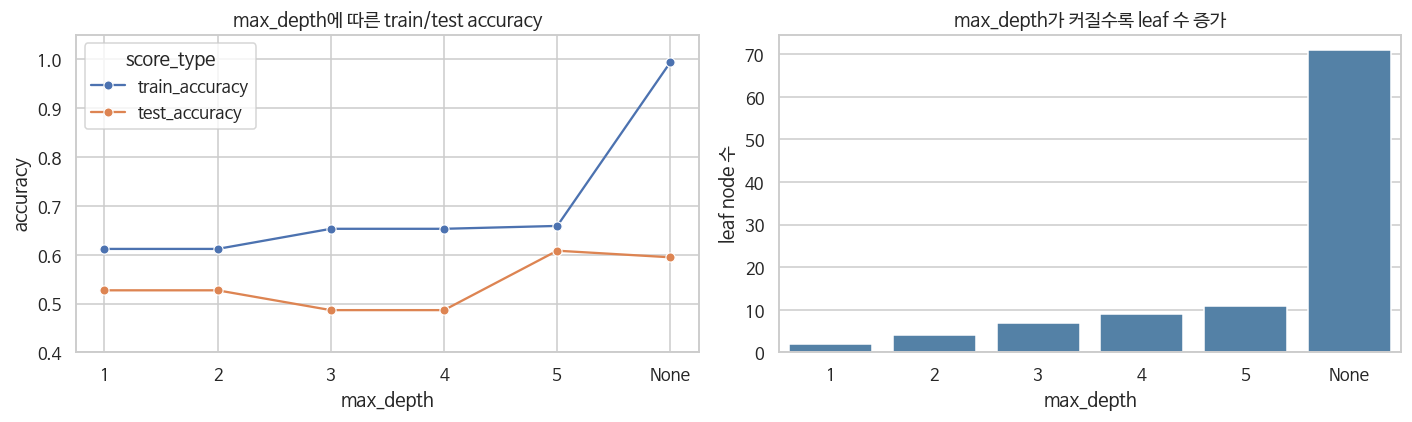

In [8]:
# 1. 시각화를 위한 1행 2열 구조의 서브플롯(Grid) 생성 (가로 13인치, 세로 4인치)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 2. 첫 번째 그래프: max_depth별 Train / Test 정확도 추이 비교
# Seaborn의 hue 옵션을 쉽게 사용하기 위해 데이터프레임을 Wide-form에서 Long-form으로 재구조화(Melt)합니다.
depth_plot_df = depth_df.melt(
    id_vars='max_depth',
    value_vars=['train_accuracy', 'test_accuracy'],
    var_name='score_type',
    value_name='accuracy',
)

# 1번째 축(axes[0])에 선 그래프 그리기 (데이터 포인트마다 동그라미 마커 'o' 표시)
sns.lineplot(data=depth_plot_df, x='max_depth', y='accuracy', hue='score_type', marker='o', ax=axes[0])
axes[0].set_ylim(0.4, 1.05) # 정확도의 비교가 명확히 보이도록 y축 범위를 0.4에서 1.05로 고정
axes[0].set_title('max_depth에 따른 train/test accuracy')

# 3. 두 번째 그래프: max_depth별 최종 리프(말단) 노드의 개수 비교
# 트리가 깊어질수록 모델이 얼마나 세부적으로 쪼개지는지(복잡해지는지) 확인합니다.
# 2번째 축(axes[1])에 막대 그래프 그리기 (차분한 steelblue 색상 적용)
sns.barplot(data=depth_df, x='max_depth', y='n_leaves', ax=axes[1], color='steelblue')
axes[1].set_title('max_depth가 커질수록 leaf 수 증가')
axes[1].set_ylabel('leaf node 수')

# 4. 레이아웃 여백 자동 조절 후 그래프 화면에 출력
plt.tight_layout()
plt.show()

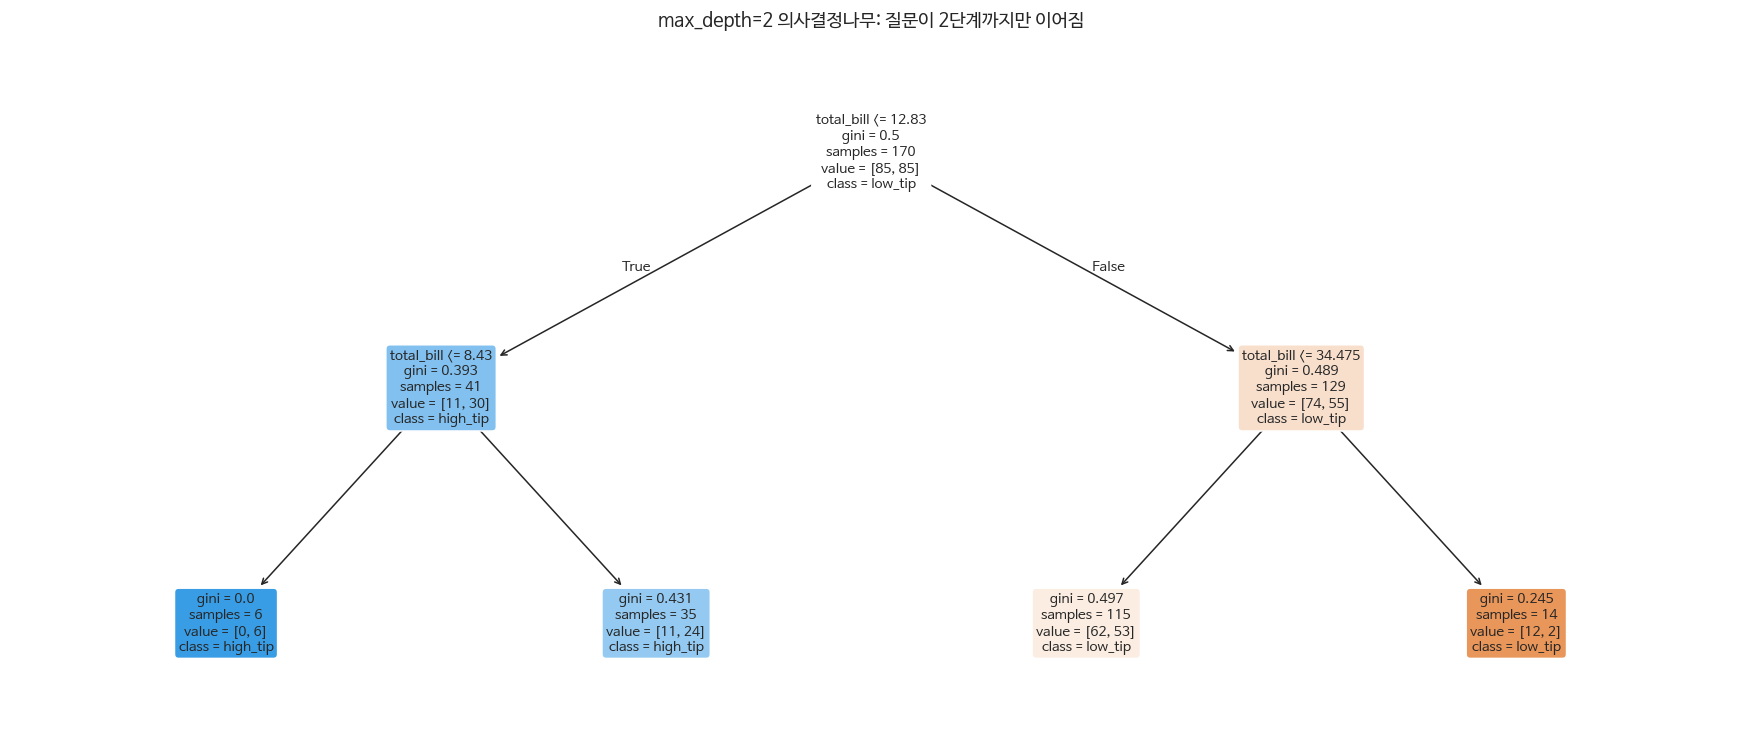

In [9]:
# 1. 시각화를 위한 캔버스 크기 설정 (트리 구조가 잘 보이도록 가로 16인치, 세로 7인치의 넓은 비율 사용)
fig, ax = plt.subplots(figsize=(16, 7))

# 2. 결정 트리 다이어그램 그리기
plot_tree(
    depth_models['2'],              # 시각화할 결정 트리 모델 객체 (max_depth=2로 학습된 모델)
    feature_names=tree_feature_cols, # 분할 기준에 표시될 독립변수(Feature) 이름 리스트
    class_names=['low_tip', 'high_tip'], # 타겟 클래스 이름 (0: low_tip, 1: high_tip)
    filled=True,                    # 다수결 클래스 비율에 따라 노드에 배경색을 채움 (진할수록 순도가 높음)
    rounded=True,                   # 노드 박스의 모서리를 둥글게 처리하여 가독성 향상
    fontsize=9,                     # 노드 내부 텍스트의 글자 크기 지정
    ax=ax,                          # 그래프를 그려넣을 축(축) 지정
)

# 3. 그래프 타이틀 설정 및 출력
ax.set_title('max_depth=2 의사결정나무: 질문이 2단계까지만 이어짐')

# 레이아웃 여백을 최적화한 후 트리 시각화 결과물 화면에 출력
plt.tight_layout()
plt.show()

---
## 4. Tree Feature Importance를 직접 계산하기

트리의 `feature_importances_`는 각 특성이 만든 **불순도 감소량**을 누적한 값입니다.

$$Importance_j = \sum_{t: split\ on\ j} \frac{n_t}{N}\Delta I_t$$

즉, 어떤 특성이 자주 쓰였는지만 보는 것이 아니라, 그 특성으로 나눴을 때 얼마나 많이 불순도를 줄였는지를 봅니다.


In [10]:
# 1. 원리 증명용 결정 트리 모델 생성 및 학습 (깊이 3으로 제한)
tree_for_importance = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=RANDOM_STATE)
tree_for_importance.fit(X_train, y_train)

# 2. 트리의 내부 구조 정보를 담고 있는 객체 접근
tree_struct = tree_for_importance.tree_
# 특성(Feature) 개수만큼 중요도를 누적할 빈 배열 생성
manual_importance = np.zeros(len(tree_feature_cols))
# 최상단 루트 노드의 전체 데이터 개수 (가중치 계산용 부모 분모 값)
root_n = tree_struct.n_node_samples[0]

# 3. 트리의 모든 노드(node_count)를 순회하며 지니 감소량 계산
for node_id in range(tree_struct.node_count):
    feature_idx = tree_struct.feature[node_id]

    # 만약 feature_idx가 음수(-2)라면, 더 이상 나눌 수 없는 말단 리프 노드이므로 패스합니다.
    if feature_idx < 0:
        continue

    # 현재 노드의 왼쪽 및 오른쪽 자식 노드의 ID 추출
    left_id = tree_struct.children_left[node_id]
    right_id = tree_struct.children_right[node_id]

    # 각 노드에 속한 샘플(데이터) 개수 추출
    node_n = tree_struct.n_node_samples[node_id]   # 현재 (부모) 노드의 샘플 수
    left_n = tree_struct.n_node_samples[left_id]    # 왼쪽 자식 노드의 샘플 수
    right_n = tree_struct.n_node_samples[right_id]  # 오른쪽 자식 노드의 샘플 수

    # 순수 불순도 감소량 계산: 현재 노드 불순도 - (자식 노드들의 가중 평균 불순도)
    impurity_decrease = (
        tree_struct.impurity[node_id]
        - (left_n / node_n) * tree_struct.impurity[left_id]
        - (right_n / node_n) * tree_struct.impurity[right_id]
    )

    # 전체 데이터 중 현재 노드가 차지하는 비율(가중치)을 곱해 '가중 불순도 감소량' 계산
    weighted_decrease = (node_n / root_n) * impurity_decrease

    # 분할에 사용된 해당 변수의 인덱스 위치에 감소량을 누적 합산
    manual_importance[feature_idx] += weighted_decrease

# 4. 전체 중요도의 합이 1이 되도록 정규화(Normalization)
manual_importance = manual_importance / manual_importance.sum()

# 5. 수동으로 계산한 중요도와 사이킷런 내부 변수 중요도 값을 데이터프레임으로 묶어 비교
tree_importance_df = pd.DataFrame({
    'feature': tree_feature_cols,
    'manual_importance': manual_importance,                       # 직접 수식으로 구한 값
    'sklearn_feature_importances_': tree_for_importance.feature_importances_, # 사이킷런이 제공하는 값
}).sort_values('manual_importance', ascending=False) # 중요도 높은 순으로 정렬

# 소수점 넷째 자리까지 반올림하여 출력
tree_importance_df.round(4)

,feature,manual_importance,sklearn_feature_importances_
0,total_bill,0.8508,0.8508
1,size,0.1492,0.1492
2,smoker_yes,0.0000,0.0000
3,dinner,0.0000,0.0000
4,weekend,0.0000,0.0000


---
## 5. 모델별 Feature Importance는 의미가 다르다

Feature Importance는 모델마다 같은 뜻이 아닙니다.

- **Linear Regression**: 계수(coefficient), 즉 기울기입니다. 특성이 1 증가할 때 예측값이 얼마나 변하는지 봅니다.
- **Logistic Regression**: log-odds에 대한 계수입니다. 부호와 크기로 방향과 영향력을 봅니다.
- **Decision Tree**: 불순도 감소량입니다.
- **KNN**: 자체 importance가 없습니다. 보통 permutation importance로 봅니다.
- **Naive Bayes**: 클래스별 평균 차이를 간단한 중요도처럼 볼 수 있습니다.
- **Neural Network**: 직접 해석이 어렵기 때문에 permutation importance나 SHAP 같은 model-agnostic 방법을 씁니다.


In [11]:
model_feature_cols = ['total_bill', 'size', 'smoker_yes', 'dinner', 'weekend']
X_model = tips.loc[:, model_feature_cols]
y_class = tips.loc[:, 'high_tip']
y_reg = tips.loc[:, 'tip']

X_train_m, X_test_m, y_train_c, y_test_c = train_test_split(
    X_model,
    y_class,
    test_size=0.3,
    stratify=y_class,
    random_state=RANDOM_STATE,
)
y_train_r = y_reg.loc[X_train_m.index]
y_test_r = y_reg.loc[X_test_m.index]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled = scaler.transform(X_test_m)

# 1. Linear Regression: 표준화된 특성의 기울기
lin = LinearRegression()
lin.fit(X_train_scaled, y_train_r)
linear_importance = pd.Series(lin.coef_, index=model_feature_cols, name='Linear coefficient')

# 2. Logistic Regression: 표준화된 특성의 log-odds 계수
logit = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logit.fit(X_train_scaled, y_train_c)
logistic_importance = pd.Series(logit.coef_[0], index=model_feature_cols, name='Logistic coefficient')

# 3. Decision Tree: 불순도 감소량 기반 importance
tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree.fit(X_train_m, y_train_c)
tree_importance = pd.Series(tree.feature_importances_, index=model_feature_cols, name='Tree impurity importance')

# 4. KNN: 모델 자체 importance가 없으므로 permutation importance 사용
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train_c)
knn_perm = permutation_importance(knn, X_test_scaled, y_test_c, n_repeats=20, random_state=RANDOM_STATE)
knn_importance = pd.Series(knn_perm.importances_mean, index=model_feature_cols, name='KNN permutation importance')

# 5. Gaussian Naive Bayes: 클래스별 평균 차이를 단순 중요도처럼 확인
nb = GaussianNB()
nb.fit(X_train_scaled, y_train_c)
nb_mean_diff = np.abs(nb.theta_[1] - nb.theta_[0])
nb_importance = pd.Series(nb_mean_diff, index=model_feature_cols, name='Naive Bayes class mean diff')

# 6. Neural Network: permutation importance로 간단히 확인
mlp = MLPClassifier(hidden_layer_sizes=(12,), max_iter=1000, random_state=RANDOM_STATE)
mlp.fit(X_train_scaled, y_train_c)
mlp_perm = permutation_importance(mlp, X_test_scaled, y_test_c, n_repeats=20, random_state=RANDOM_STATE)
mlp_importance = pd.Series(mlp_perm.importances_mean, index=model_feature_cols, name='Neural Net permutation importance')

importance_by_model = pd.concat([
    linear_importance,
    logistic_importance,
    tree_importance,
    knn_importance,
    nb_importance,
    mlp_importance,
], axis=1)

importance_by_model.round(4)


,Linear coefficient,Logistic coefficient,Tree impurity importance,KNN permutation importance,Naive Bayes class mean diff,Neural Net permutation importance
total_bill,0.8448,-0.6575,0.8508,0.0162,0.4502,0.0993
size,0.2974,0.2568,0.1492,-0.0459,0.1051,-0.0338
smoker_yes,0.0217,0.0706,0.0000,-0.0601,0.0242,-0.0182
dinner,0.0358,0.0772,0.0000,-0.0115,0.0530,-0.0196
weekend,0.0253,0.0723,0.0000,-0.0399,0.0748,-0.0054


In [12]:
# 1. 특성(Feature) 및 분류/회귀 타겟 변수 설정
model_feature_cols = ['total_bill', 'size', 'smoker_yes', 'dinner', 'weekend']
X_model = tips.loc[:, model_feature_cols]
y_class = tips.loc[:, 'high_tip'] # 분류(Classification)용 타겟 (0 또는 1)
y_reg = tips.loc[:, 'tip']        # 회귀(Regression)용 타겟 (연속형 변수인 팁 금액)

# 2. 데이터셋 분리 (학습용 7 : 테스트용 3)
X_train_m, X_test_m, y_train_c, y_test_c = train_test_split(
    X_model,
    y_class,
    test_size=0.3,
    stratify=y_class, # 분류 타겟의 비율을 균등하게 분할
    random_state=RANDOM_STATE,
)
# 회귀용 타겟도 인덱스를 맞춰 동일하게 분리
y_train_r = y_reg.loc[X_train_m.index]
y_test_r = y_reg.loc[X_test_m.index]

# 3. 데이터 표준화(Standardization) 스케일링 적용
# 선형 모델, KNN, 신경망 등 거리에 민감한 모델들을 위해 평균 0, 분산 1로 스케일링합니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled = scaler.transform(X_test_m)

# ----------------------------------------------------
# 4. 모델별 특성 중요도 추출
# ----------------------------------------------------

# (1) 선형 회귀(Linear Regression): 팁 금액 예측
# 스케일링된 상태이므로, 회귀 계수(coef_)의 절대값이 클수록 영향력이 큰 변수입니다.
lin = LinearRegression()
lin.fit(X_train_scaled, y_train_r)
linear_importance = pd.Series(lin.coef_, index=model_feature_cols, name='Linear coefficient')

# (2) 로지스틱 회귀(Logistic Regression): high_tip 여부 분류
# 계수(coef_)는 해당 특성이 1단위 증가할 때의 로그 오즈(Log-Odds) 변화량을 뜻합니다.
logit = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logit.fit(X_train_scaled, y_train_c)
logistic_importance = pd.Series(logit.coef_[0], index=model_feature_cols, name='Logistic coefficient')

# (3) 결정 트리(Decision Tree): 트리 기반 불순도 감소량
# 트리가 분할될 때 지니 불순도를 얼마나 낮췄는가를 기준으로 가중치 합을 구합니다. (스케일링 무관)
tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree.fit(X_train_m, y_train_c)
tree_importance = pd.Series(tree.feature_importances_, index=model_feature_cols, name='Tree impurity importance')

# (4) KNN: 알고리즘 자체의 중요도가 없으므로 순열 중요도(Permutation Importance) 활용
# 테스트 데이터의 특정 변수를 무작위로 섞었을 때(수정을 가했을 때) 모델의 정확도가 얼마나 떨어지는지 측정합니다.
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_scaled_train := X_train_scaled, y_train_c)
knn_perm = permutation_importance(knn, X_test_scaled, y_test_c, n_repeats=20, random_state=RANDOM_STATE)
knn_importance = pd.Series(knn_perm.importances_mean, index=model_feature_cols, name='KNN permutation importance')

# (5) 나이브 베이즈(Gaussian NB): 두 클래스 간의 평균값 차이
# high_tip이 1인 그룹과 0인 그룹 간에 해당 변수의 평균값 차이(절대값)를 기여도로 가정합니다.
nb = GaussianNB()
nb.fit(X_train_scaled, y_train_c)
nb_mean_diff = np.abs(nb.theta_[1] - nb.theta_[0])
nb_importance = pd.Series(nb_mean_diff, index=model_feature_cols, name='Naive Bayes class mean diff')

# (6) 인공신경망(MLP Classifier): 순열 중요도(Permutation Importance) 활용
# 블랙박스 모델인 신경망 구조에서 각 특성이 예측 성능을 유지하는 데 기여하는 정도를 측정합니다.
mlp = MLPClassifier(hidden_layer_sizes=(12,), max_iter=1000, random_state=RANDOM_STATE)
mlp.fit(X_train_scaled, y_train_c)
mlp_perm = permutation_importance(mlp, X_test_scaled, y_test_c, n_repeats=20, random_state=RANDOM_STATE)
mlp_importance = pd.Series(mlp_perm.importances_mean, index=model_feature_cols, name='Neural Net permutation importance')

# ----------------------------------------------------
# 5. 모든 모델의 중요도 지표를 하나의 데이터프레임으로 병합
# ----------------------------------------------------
importance_by_model = pd.concat([
    linear_importance,
    logistic_importance,
    tree_importance,
    knn_importance,
    nb_importance,
    mlp_importance,
], axis=1)

# 가독성을 위해 소수점 넷째 자리까지 반올림하여 출력
importance_by_model.round(4)

,Linear coefficient,Logistic coefficient,Tree impurity importance,KNN permutation importance,Naive Bayes class mean diff,Neural Net permutation importance
total_bill,0.8448,-0.6575,0.8508,0.0162,0.4502,0.0993
size,0.2974,0.2568,0.1492,-0.0459,0.1051,-0.0338
smoker_yes,0.0217,0.0706,0.0000,-0.0601,0.0242,-0.0182
dinner,0.0358,0.0772,0.0000,-0.0115,0.0530,-0.0196
weekend,0.0253,0.0723,0.0000,-0.0399,0.0748,-0.0054


---
## 6. 모델별 특성 엔지니어링 관점

| 모델 계열 | 중요한 특성 엔지니어링 | 이유 |
|---|---|---|
| 선형회귀·로지스틱 회귀 | 스케일링, 로그변환, 상호작용항, 다중공선성 관리 | 계수 크기와 규제가 스케일에 민감하고 선형 관계를 가정 |
| KNN·거리 기반 SVM | 표준화/정규화, 불필요한 특성 제거 | 거리 계산에서 큰 스케일 특성이 전체 거리를 지배 |
| 트리·랜덤포레스트·GBM | 범주 인코딩, 결측 처리, 의미 있는 비닝·파생변수 | 스케일에는 둔감하지만 좋은 분할 후보가 필요 |
| 나이브 베이즈 | 분포 가정에 맞는 변환, 희소 범주 정리 | Gaussian/Multinomial 등 가정과 입력 표현이 직접 연결 |
| 신경망 | 스케일링, 임베딩, 안정적 수치 범위 | 최적화와 gradient 안정성에 큰 영향 |
| 시계열 모델 | lag, rolling mean, rolling std, 미래 정보 제거 | 시간 순서와 누수 방지가 핵심 |

이 표의 핵심은 **모델이 데이터를 보는 방식이 다르기 때문에 필요한 특성 엔지니어링도 다르다**는 점입니다.


---
## 7. tips 데이터로 쉬운 특성 엔지니어링 만들기

새 데이터를 추가하지 않고 기존 컬럼으로만 특성을 만듭니다.

- `log_total_bill`: 큰 금액의 영향을 완만하게 만드는 로그변환
- `bill_per_person`: 1인당 결제 금액
- `large_party`: 인원 수가 4명 이상인지
- `bill_x_size`: 결제 금액과 인원 수의 상호작용
- `day`, `time`, `smoker` 원-핫 인코딩


In [13]:
# 1. 원본 데이터 보호를 위해 복사본 생성
tips_fe = tips.copy()

# 2. 파생 변수 생성 (Feature Engineering)
# 왜도가 심한(한쪽으로 치우친) total_bill 데이터의 분포를 정규분포에 가깝게 만들기 위해 로그 변환을 적용합니다. (log1p는 log(x+1)을 의미하여 0 처리 오류를 방지합니다.)
tips_fe.loc[:, 'log_total_bill'] = np.log1p(tips_fe.loc[:, 'total_bill'])

# 인당 식사 금액(전체 금액 / 일행 수)을 계산하여 컬럼을 생성합니다.
tips_fe.loc[:, 'bill_per_person'] = tips_fe.loc[:, 'total_bill'] / tips_fe.loc[:, 'size']

# 일행 수가 4명 이상인 대규모 손님군인지 여부를 이진화(0 또는 1)합니다.
tips_fe.loc[:, 'large_party'] = (tips_fe.loc[:, 'size'] >= 4).astype(int)

# 전체 금액과 일행 수 간의 상호작용(Interaction)을 표현하기 위해 두 변수를 곱한 컬럼을 생성합니다.
tips_fe.loc[:, 'bill_x_size'] = tips_fe.loc[:, 'total_bill'] * tips_fe.loc[:, 'size']

# 3. 범주형 변수의 원-핫 인코딩 (One-Hot Encoding)
# 문자열 데이터(day, time, smoker)를 모델이 이해할 수 있도록 0과 1의 더미 변수로 변환합니다.
# drop_first=True를 설정하여 다중공선성 문제를 방지하기 위해 첫 번째 카테고리를 제외합니다. (예: smoker_No 제외 후 smoker_Yes만 남김)
category_dummies = pd.get_dummies(
    tips_fe.loc[:, ['day', 'time', 'smoker']],
    drop_first=True,
    dtype=int,
)

# 4. 모델 검증 비교를 위한 특성 그룹 분리
base_features = ['total_bill', 'size'] # 기본 변수 그룹
engineered_features = ['total_bill', 'size', 'log_total_bill', 'bill_per_person', 'large_party', 'bill_x_size'] # 파생 변수 그룹

X_base = tips_fe.loc[:, base_features] # 실험 1: 기본 변수만 사용한 데이터셋

# 실험 2: 파생 변수와 원-핫 인코딩된 범주형 변수를 결합한 확장 데이터셋
X_engineered = pd.concat([tips_fe.loc[:, engineered_features], category_dummies], axis=1)

# 타겟 변수 설정 (예측하고자 하는 팁 금액)
y_tip = tips_fe.loc[:, 'tip']

# 5. 데이터 구조 및 결과 출력
print('기본 특성 수:', X_base.shape[1])
print('엔지니어링 후 특성 수:', X_engineered.shape[1])

# 전처리와 변수 생성이 완료된 데이터프레임의 상위 5개 행 출력
X_engineered.head()

기본 특성 수: 2
엔지니어링 후 특성 수: 11


,total_bill,size,log_total_bill,bill_per_person,large_party,bill_x_size,day_Fri,day_Sat,day_Sun,time_Dinner,smoker_No
0,16.99,2,2.889816,8.495000,0,33.98,0,0,1,1,1
1,10.34,3,2.428336,3.446667,0,31.02,0,0,1,1,1
2,21.01,3,3.091497,7.003333,0,63.03,0,0,1,1,1
3,23.68,2,3.205993,11.840000,0,47.36,0,0,1,1,1
4,24.59,4,3.242202,6.147500,1,98.36,0,0,1,1,1


In [14]:
# 1. 두 가지 변수 그룹(기본 vs 파생)에 대해 각각 Train/Test 세트 분리
# 기본 특성 데이터셋 분리
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base,
    y_tip,
    test_size=0.3,
    random_state=RANDOM_STATE,
)
# 엔지니어링된 특성 데이터셋 분리
Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_engineered,
    y_tip,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

# 2. 선형 회귀 평가를 위한 평가지표 함수 정의 (Root Mean Squared Error)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# 3. 모델별 데이터 전처리 조건 및 루프 실행
fe_results = []

# (모델 라벨, Train X, Test X, Train y, Test y, 스케일링 여부) 리스트를 정의하고 순회합니다.
for label, Xtr, Xte, ytr, yte, scale in [
    ('Linear - base', Xb_train, Xb_test, yb_train, yb_test, True),
    ('Linear - engineered', Xe_train, Xe_test, ye_train, ye_test, True),
    ('KNN - base raw', Xb_train, Xb_test, yb_train, yb_test, False),       # 스케일링 미적용 KNN
    ('KNN - base scaled', Xb_train, Xb_test, yb_train, yb_test, True),     # 스케일링 적용 KNN
    ('KNN - engineered scaled', Xe_train, Xe_test, ye_train, ye_test, True),
    ('Tree - base', Xb_train, Xb_test, yb_train, yb_test, False),
    ('Tree - engineered', Xe_train, Xe_test, ye_train, ye_test, False),
]:
    # 3-1. 모델 정의 및 타겟 변수 변환
    if label.startswith('Linear'):
        # 선형 회귀 모델: 연속형 변수(tip 금액)를 그대로 타겟으로 사용
        model = LinearRegression()
    elif label.startswith('KNN'):
        # KNN 모델: 타겟을 중앙값 기준으로 이진화(0 또는 1)하여 분류 문제로 전환
        model = KNeighborsClassifier(n_neighbors=15)
        ytr = (ytr >= y_tip.median()).astype(int)
        yte = (yte >= y_tip.median()).astype(int)
    else:
        # 결정 트리 모델: 타겟을 중앙값 기준으로 이진화(0 또는 1)하여 분류 문제로 전환
        model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
        ytr = (ytr >= y_tip.median()).astype(int)
        yte = (yte >= y_tip.median()).astype(int)

    # 3-2. 스케일링 설정에 따른 데이터 전처리 실행
    if scale:
        sc = StandardScaler()
        Xtr_fit = sc.fit_transform(Xtr) # 학습 데이터에 맞춰 스케일러 피팅 후 변환
        Xte_fit = sc.transform(Xte)     # 테스트 데이터는 학습용 스케일러 기준으로 변환
    else:
        Xtr_fit = Xtr
        Xte_fit = Xte

    # 3-3. 모델 학습 및 예측
    model.fit(Xtr_fit, ytr)
    pred = model.predict(Xte_fit)

    # 3-4. 문제 유형(회귀 또는 분류)에 맞춰 알맞은 평가지표 계산
    metric = rmse(yte, pred) if label.startswith('Linear') else accuracy_score(yte, pred)

    # 결과 저장
    fe_results.append({
        'model': label,
        'metric': metric,
        'metric_name': 'RMSE' if label.startswith('Linear') else 'Accuracy'
    })

# 4. 전체 실험 결과들을 통합 데이터프레임으로 변환하여 확인
fe_result_df = pd.DataFrame(fe_results)
fe_result_df

,model,metric,metric_name
0,Linear - base,0.918076,RMSE
1,Linear - engineered,0.984363,RMSE
2,KNN - base raw,0.716216,Accuracy
3,KNN - base scaled,0.729730,Accuracy
4,KNN - engineered scaled,0.675676,Accuracy
5,Tree - base,0.729730,Accuracy
6,Tree - engineered,0.689189,Accuracy


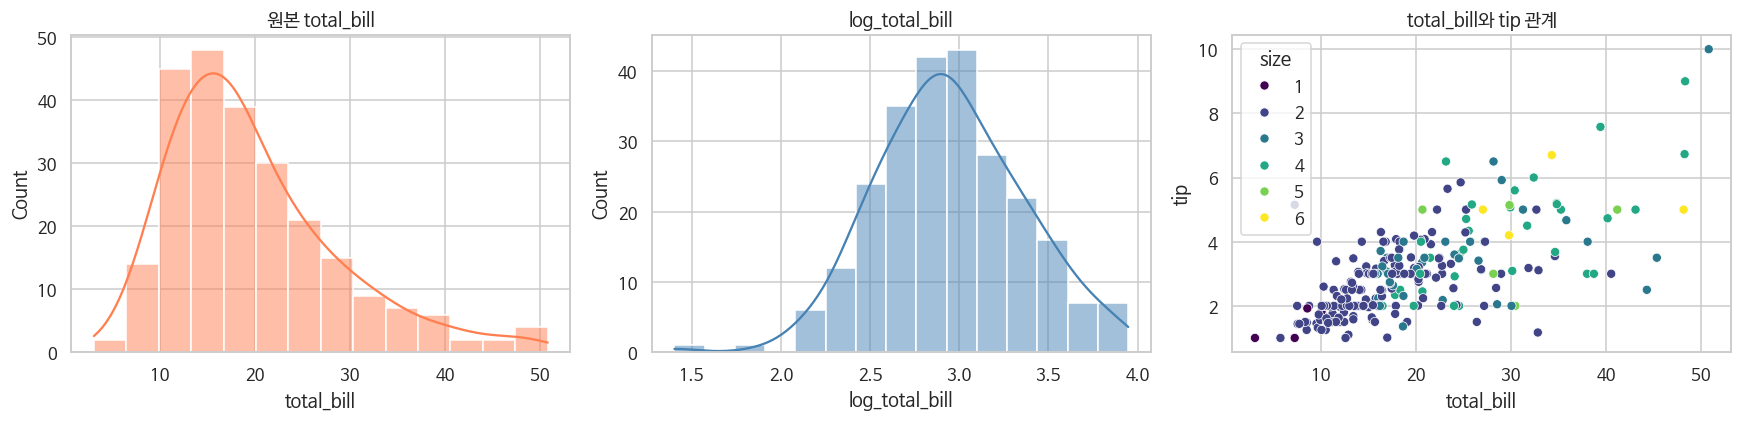

In [15]:
# 1. 시각화를 위한 1행 3열 구조의 서브플롯(Grid) 생성 (가로 16인치, 세로 4인치)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 2. 첫 번째 그래프: 원본 total_bill 변수의 히스토그램 및 밀도 함수(KDE)
# 데이터가 왼쪽으로 치우치고 오른쪽으로 긴 꼬리를 갖는 왜도(Skewness)가 존재하는지 확인합니다.
sns.histplot(tips_fe.loc[:, 'total_bill'], kde=True, ax=axes[0], color='coral')
axes[0].set_title('원본 total_bill')

# 3. 두 번째 그래프: 로그 변환(log1p)을 적용한 데이터의 히스토그램 및 밀도 함수
# 치우쳐 있던 데이터가 로그 변환을 통해 정규분포(종 모양)에 얼마나 가까워졌는지 대조합니다.
sns.histplot(tips_fe.loc[:, 'log_total_bill'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('log_total_bill')

# 4. 세 번째 그래프: 두 연속형 변수(total_bill, tip) 간의 상관관계를 보여주는 산점도(Scatter plot)
# 점의 색상(hue)을 일행 수('size')로 지정하고, 자연스러운 그라데이션인 'viridis' 색상표를 적용했습니다.
sns.scatterplot(data=tips_fe, x='total_bill', y='tip', hue='size', palette='viridis', ax=axes[2])
axes[2].set_title('total_bill와 tip 관계')

# 5. 그래프 간격이 겹치지 않도록 자동 정돈 후 화면에 출력
plt.tight_layout()
plt.show()

---
## 8. 정리

오늘의 핵심은 매우 단순합니다.

1. 의사결정나무는 **어떤 질문으로 나눌까?** 를 반복하는 모델입니다.
2. Gini와 Entropy는 노드가 얼마나 섞여 있는지 계산하는 방법입니다.
3. 좋은 분할조건은 부모보다 자식 노드의 불순도를 많이 줄이는 조건입니다.
4. `max_depth`가 작으면 단순하고, 너무 크면 학습 데이터를 외울 수 있습니다.
5. Feature Importance는 모델마다 의미가 다릅니다. 선형모델은 계수, 트리는 불순도 감소량, KNN/신경망은 보통 permutation importance로 봅니다.
6. 특성 엔지니어링은 모델의 성격에 맞춰 해야 합니다. 선형·거리 기반 모델은 스케일링이 중요하고, 트리는 좋은 분할 후보가 중요합니다.
